# Local economic conditions and public–lender loss sharing in SBA 7(a) lending

**Research walkthrough — frozen results, 8 October 2026**

How does recorded charge-off risk vary across cohorts and local economic conditions,
and how are assumption-based losses allocated between SBA and lenders?

This notebook follows the complete analytical pipeline and displays the accepted
saved results. **Run All works without raw borrower data, model objects, network
access or new estimation.** Model estimation is explained, rather than silently
rerun. The optional private re-estimation guide is disabled by default.

Sections: sources and sample → design and chronology → scorecard validation →
calibration → macro associations → scenario PD/loss sharing → sensitivities →
diagnostics and full result catalogue → private replication requirements.
All numerical displays come from saved aggregates or the claims registry.


In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import HTML, Image, Markdown, display

ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "PUBLIC_RELEASE_MANIFEST.json").is_file()
)
sys.path.insert(0, str(ROOT))
from reporting.checks import verify_claims
from reporting.registry import Registry

SOURCE = ROOT / "results/g2-bis-2026-10-08"
payload = json.loads((ROOT / "results/g5-2026-10-08/claims_registry.json").read_text())
provenance = verify_claims(ROOT, payload)
registry = Registry(ROOT)
registry.entries, registry.aliases = payload["claims"], payload["aliases"]
config = yaml.safe_load((ROOT / "config/g2_bis_2026-10-08.yaml").read_text())
RESULTS = {
    str(path.relative_to(ROOT)): pd.read_csv(path)
    for path in sorted((ROOT / "results").rglob("*.csv"))
}
tables = {
    path.stem: RESULTS[str(path.relative_to(ROOT))]
    for path in sorted(SOURCE.glob("*.csv"))
}
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

def show(frame, title=None, rows=None):
    if title:
        display(Markdown("**" + title + "**"))
    display(HTML(frame.to_html(index=False, max_rows=rows, float_format=lambda v: f"{v:,.4f}")))

def show_result(path, rows=None):
    key = path if path in RESULTS else "results/g2-bis-2026-10-08/" + path
    show(RESULTS[key], key, rows=rows)

def select(frame, **values):
    mask = pd.Series(True, index=frame.index)
    for column, value in values.items():
        mask &= frame[column].eq(value)
    return frame.loc[mask].copy()

print("Mode: frozen aggregate results only; no model fitting or acquisition.")
print("Provenance:", provenance)


Mode: frozen aggregate results only; no model fitting or acquisition.
Provenance: {'verified_cells': 4573, 'derived_cells': 5, 'source_files': 20}


## 1. Economic question and data

SBA guarantees redistribute potential credit losses between public and private
balance sheets. An origination scorecard can rank loans while failing to transfer
its probability level across economic regimes. We therefore distinguish
discrimination, calibration, conditional macro associations and loss accounting.

Loan source: official SBA 7(a) FOIA files, snapshot **30 June 2026**, with loans of
all disclosed statuses and complete 36-month outcome windows. Macro sources:
direct BLS state unemployment and FHFA all-transactions state HPI. Observations
are revised histories, not historical real-time releases. The outcome is
**recorded charge-off within 36 months of first disbursement**, not delinquency.

The source audit and selection rules are in `DATA.md` and the fixed protocols.
This product uses FHFA data but is neither endorsed nor certified by FHFA.

Cohort plots describe the eligible disclosed sample. Boundary years are partial;
in particular, 2023 includes only disbursements with a mature outcome window by
the snapshot cutoff. They are not full-year population incidence estimates.


In [2]:
show(tables["source_population_waterfall"], "Source-to-eligible population waterfall")
show(tables["final_sample_waterfall_complete"], "Final samples and temporal roles")


**Source-to-eligible population waterfall**

step,excluded,remaining
all_source_rows,0,1961455
wrong_program,0,1961455
cancelled_or_committed,263913,1697542
unknown_status,0,1697542
missing_disbursement,1795,1695747
incomplete_window,160527,1535220
invalid_approval_amount,1,1535219
unmapped_state,18730,1516489
date_or_status_contradiction,1637,1514852


**Final samples and temporal roles**

layer,role,years,eligible_n,macro_excluded_n,n,events,non_events,earliest_disbursement,latest_disbursement,latest_label_window,latest_required_unemployment_year,full_monthly_path_levels,full_HPI_window_quarters,interpretation,layer_interpretation
layer1,estimation,1991-2002,405443,0,405443,14003,391440,1991-01-02 00:00:00,2002-12-31 00:00:00,2005-12-31 00:00:00,2005,37,13,Approval-descriptor prediction,Approval-descriptor prediction
layer1,crisis,2007-2009,181311,0,181311,22212,159099,2007-01-01 00:00:00,2009-12-31 00:00:00,2012-12-31 00:00:00,2012,37,13,Approval-descriptor prediction,Approval-descriptor prediction
layer1,additional_check,2011-2013,120002,0,120002,1787,118215,2011-01-01 00:00:00,2013-12-31 00:00:00,2016-12-31 00:00:00,2016,37,13,Approval-descriptor prediction,Approval-descriptor prediction
layer2,estimation,1991-2009,888703,0,888703,55088,833615,1991-01-02 00:00:00,2009-12-31 00:00:00,2012-12-31 00:00:00,2012,37,13,Retrospective conditional validation using realized macro paths.,Retrospective conditional validation using realized macro paths.
layer2,tree_calibration,2010-2010,41200,0,41200,918,40282,2010-01-01 00:00:00,2010-12-31 00:00:00,2013-12-31 00:00:00,2013,37,13,Retrospective conditional validation using realized macro paths.,Retrospective conditional validation using realized macro paths.
layer2,heldout_check,2013-2014,87156,0,87156,1289,85867,2013-01-01 00:00:00,2014-12-31 00:00:00,2017-12-31 00:00:00,2017,37,13,Retrospective conditional validation using realized macro paths.,Retrospective conditional validation using realized macro paths.
scenario,reference,2006-2006,89002,0,89002,8428,80574,2006-01-05 00:00:00,2006-12-31 00:00:00,2009-12-31 00:00:00,2009,37,13,"Fixed scenario portfolio; included in Layer 2 estimation, not OOS validation","Fixed scenario portfolio; included in Layer 2 estimation, not OOS validation"
layer1,benchmark_calibration_2003H2,2003H2,31955,0,31955,1426,30529,2003-07-02,2003-12-31,2006-12-31 00:00:00,2006,37,13,Approval-descriptor benchmark calibration only; raw Firth remains uncalibrated,NaN


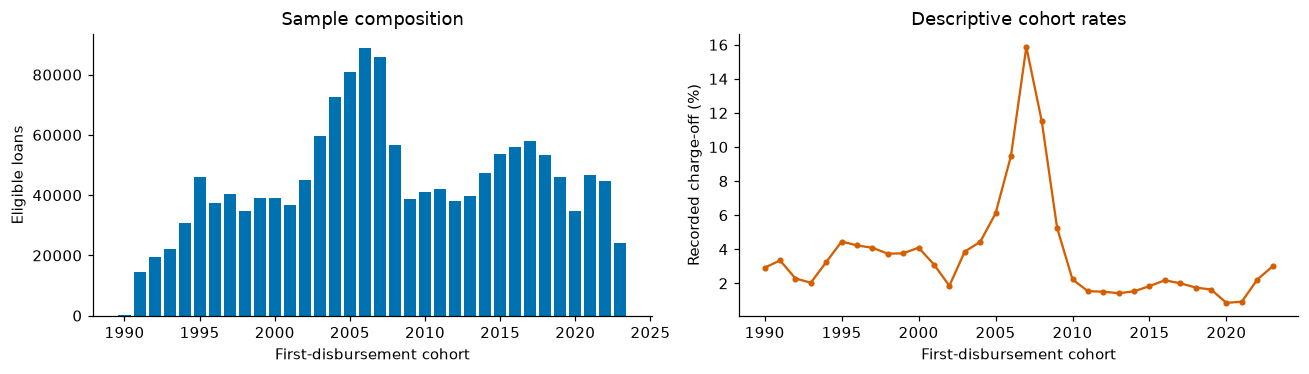

**All cohort counts and recorded rates**

year,eligible,events,macro_matched,non_events,macro_exclusions,recorded_rate_pct
"1,990.0000",274,8,274,266,0,2.9197
"1,991.0000",14415,482,14415,13933,0,3.3437
"1,992.0000",19579,447,19579,19132,0,2.2831
"1,993.0000",22040,449,22040,21591,0,2.0372
"1,994.0000",30891,1003,30891,29888,0,3.2469
"1,995.0000",46105,2053,46105,44052,0,4.4529
"1,996.0000",37407,1581,37407,35826,0,4.2265
"1,997.0000",40340,1647,40340,38693,0,4.0828
"1,998.0000",34592,1294,34592,33298,0,3.7407
"1,999.0000",39098,1470,39098,37628,0,3.7598


In [3]:
cohort = tables["cohort_counts"].copy()
cohort["recorded_rate_pct"] = 100 * cohort["events"] / cohort["eligible"]
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].bar(cohort["year"], cohort["eligible"], color="#0072B2")
axes[0].set(xlabel="First-disbursement cohort", ylabel="Eligible loans", title="Sample composition")
axes[1].plot(cohort["year"], cohort["recorded_rate_pct"], color="#D55E00", marker=".")
axes[1].set(xlabel="First-disbursement cohort", ylabel="Recorded charge-off (%)", title="Descriptive cohort rates")
fig.tight_layout()
plt.show()
show(cohort, "All cohort counts and recorded rates")


## 2. Feature construction, models and chronology

**Layer 1:** Firth logit uses approval descriptors and state effects; fits use
1991–2002, benchmark settings were chosen on 2003H1, benchmark calibration uses
2003H2, and checks use 2007–2009 and 2011–2013.

**Layer 2:** Firth logit adds realized or stipulated state macro paths and a
linear disbursement-year trend; fits use 1991–2009, tree calibration uses 2010,
and conditional validation uses 2013–2014. Future macro paths make this
**retrospective conditional validation, not real-time approval prediction**.
Calibration labels overlap the 2013 validation calendar; that cohort had
already been inspected. The 2006 scenario portfolio enters Layer 2 estimation.

Firth is primary because ordinary logits do not yield valid finite estimates
under the accepted design. Finite Firth coefficients do not prove calibration.
ElasticNet and LightGBM are fixed-setting predictive benchmarks/robustness.
Primary models exclude Term and InitialInterestRate. Frequency pooling uses
training counts only; state effects remain separate. Imputation, scaling and
category maps use training data only.

**Design history:** the Firth specification was frozen after the initial failed
logit/calibration results were seen, and before the Firth fits. This is a
post-results amendment; see `docs/METHOD_HISTORY.md`.


In [4]:
design_choices = pd.DataFrame([
    {"Choice": "Outcome", "Fixed rule": config["outcome"]},
    {"Choice": "Primary estimator", "Fixed rule": "Firth logit, Term-free"},
    {"Choice": "Frequency pooling", "Fixed rule": f"Training share < {config['categorical_pooling']['threshold']}; ProjectState excluded"},
    {"Choice": "Inference", "Fixed rule": f"{config['bootstrap']['attempts']} positive state-weighted re-estimation attempts"},
    {"Choice": "Seed", "Fixed rule": str(config["seed"])},
    {"Choice": "Reference portfolio", "Fixed rule": str(config["reference_year"])},
])
show(design_choices, "Fixed design choices")
show(tables["initial_interest_rate_missingness"], "Rate missingness: excluded shared predictor")
show(tables["design_rank_checks"], "Training design and state effects")
show(tables["layer1_pooled_level_counts"], "Layer 1 pooled levels: diagnostic events/non-events", rows=12)
show(tables["layer2_pooled_level_counts"], "Layer 2 pooled levels", rows=12)


**Fixed design choices**

Choice,Fixed rule
Outcome,recorded charge-off within 36 months
Primary estimator,"Firth logit, Term-free"
Frequency pooling,Training share < 0.001; ProjectState excluded
Inference,199 positive state-weighted re-estimation attempts
Seed,20261008
Reference portfolio,2006


**Rate missingness: excluded shared predictor**

years,eligible_n,missing_n,missing_share,specification
1991-2002,405443,405443,1.0000,Excluded from all shared specifications for historical comparability
1991-2009,888703,852023,0.9587,Excluded from all shared specifications for historical comparability


**Training design and state effects**

variant,n,events,full_columns,rank,states,state_dummy_columns,dropped,preprocessing_sha256,specification_role,layer_interpretation
layer1,405443,14003,96,93,51,50,log_approval__missing | guarantee_share__missing | log_jobs__missing,ed942340afcc58ebe638a92282fabfb27f9de56cb5f2e9d5d6fe6a9b654271d1,Term-free primary specification,Approval-descriptor prediction
layer1_term,405443,14003,98,94,51,50,log_approval__missing | guarantee_share__missing | log_jobs__missing | TermInMonths__missing,fbf3f320e09b636a8854bb7b073327049dd414ed817bea1fcf0de398d95c521c,With-Term sensitivity; reported-term timing unverified,Approval-descriptor prediction
layer2,888703,55088,115,107,51,50,log_approval__missing | guarantee_share__missing | log_jobs__missing | u0__missing | du__missing | h0__missing | dh__missing | year_trend__missing,5ee1bd4dd47b6dad4eb331a393ba7eabcce11b69225e360f2ceae1773ceb7f6d,Term-free primary specification,Retrospective conditional validation using realized macro paths.
layer2_term,888703,55088,117,108,51,50,log_approval__missing | guarantee_share__missing | log_jobs__missing | TermInMonths__missing | u0__missing | du__missing | h0__missing | dh__missing | year_trend__missing,2015e8352e8305b34b6f3afb362666d1f694d2dbb5e286d1c21fd003fbf734e8,With-Term sensitivity; reported-term timing unverified,Retrospective conditional validation using realized macro paths.
layer2_peak,888703,55088,115,107,51,50,log_approval__missing | guarantee_share__missing | log_jobs__missing | u0__missing | peak_du__missing | h0__missing | dh__missing | year_trend__missing,ec3b1fca5c0cb062d70c09cd43d292aeda7896f1a295bddc26d229ec9d98ea00,Term-free peak-unemployment sensitivity,Retrospective conditional validation using realized macro paths.


**Layer 1 pooled levels: diagnostic events/non-events**

feature,level,n,events,non_events
ProcessingMethod,7a General,103716,2894,100822
ProcessingMethod,7a with EWCP,1897,35,1862
ProcessingMethod,Certified Lenders Program,44960,984,43976
ProcessingMethod,Community Express,1311,117,1194
ProcessingMethod,International Trade Loans,948,14,934
ProcessingMethod,Low Documentation Program,102812,6044,96768
...,...,...,...,...
ProjectState,VA,5305,203,5102
ProjectState,VT,3081,93,2988
ProjectState,WA,10688,225,10463


**Layer 2 pooled levels**

feature,level,n,events,non_events,layer_interpretation
ProcessingMethod,7a General,135799,3843,131956,Retrospective conditional validation using realized macro paths.
ProcessingMethod,7a with EWCP,2488,42,2446,Retrospective conditional validation using realized macro paths.
ProcessingMethod,Certified Lenders Program,47516,1026,46490,Retrospective conditional validation using realized macro paths.
ProcessingMethod,Community Express,38795,8133,30662,Retrospective conditional validation using realized macro paths.
ProcessingMethod,Export Express,1130,90,1040,Retrospective conditional validation using realized macro paths.
ProcessingMethod,Gulf Opportunity Pilot Loan Program,1371,71,1300,Retrospective conditional validation using realized macro paths.
...,...,...,...,...,...
ProjectState,VA,12873,939,11934,Retrospective conditional validation using realized macro paths.
ProjectState,VT,5077,137,4940,Retrospective conditional validation using realized macro paths.
ProjectState,WA,23028,1011,22017,Retrospective conditional validation using realized macro paths.


## 3. Main findings from the claim ledger

Intervals below are the saved intervals, with explicit units. No fresh interval,
fit, threshold selection or diagnostic estimation is performed here.


**Registered headline quantities**

Claim,Saved display,Units
auc_crisis,"0.607 [0.587, 0.626]",AUC (unitless)
pd_crisis,5.73,percent (%)
auc_later,"0.666 [0.638, 0.691]",AUC (unitless)
pd_later,4.50,percent (%)
pd_l2_firth,2.80,percent (%)
pd_l2_tree,1.51,percent (%)
tree_calibration_intercept,"-0.431 [-0.835, -0.112]",calibration_intercept (unitless)
tree_calibration_slope,"0.894 [0.812, 0.967]",calibration_slope (unitless)
endpoint,"0.535 [0.266, 0.772]",probability percentage points (pp)
peak,"0.679 [0.439, 0.933]",probability percentage points (pp)


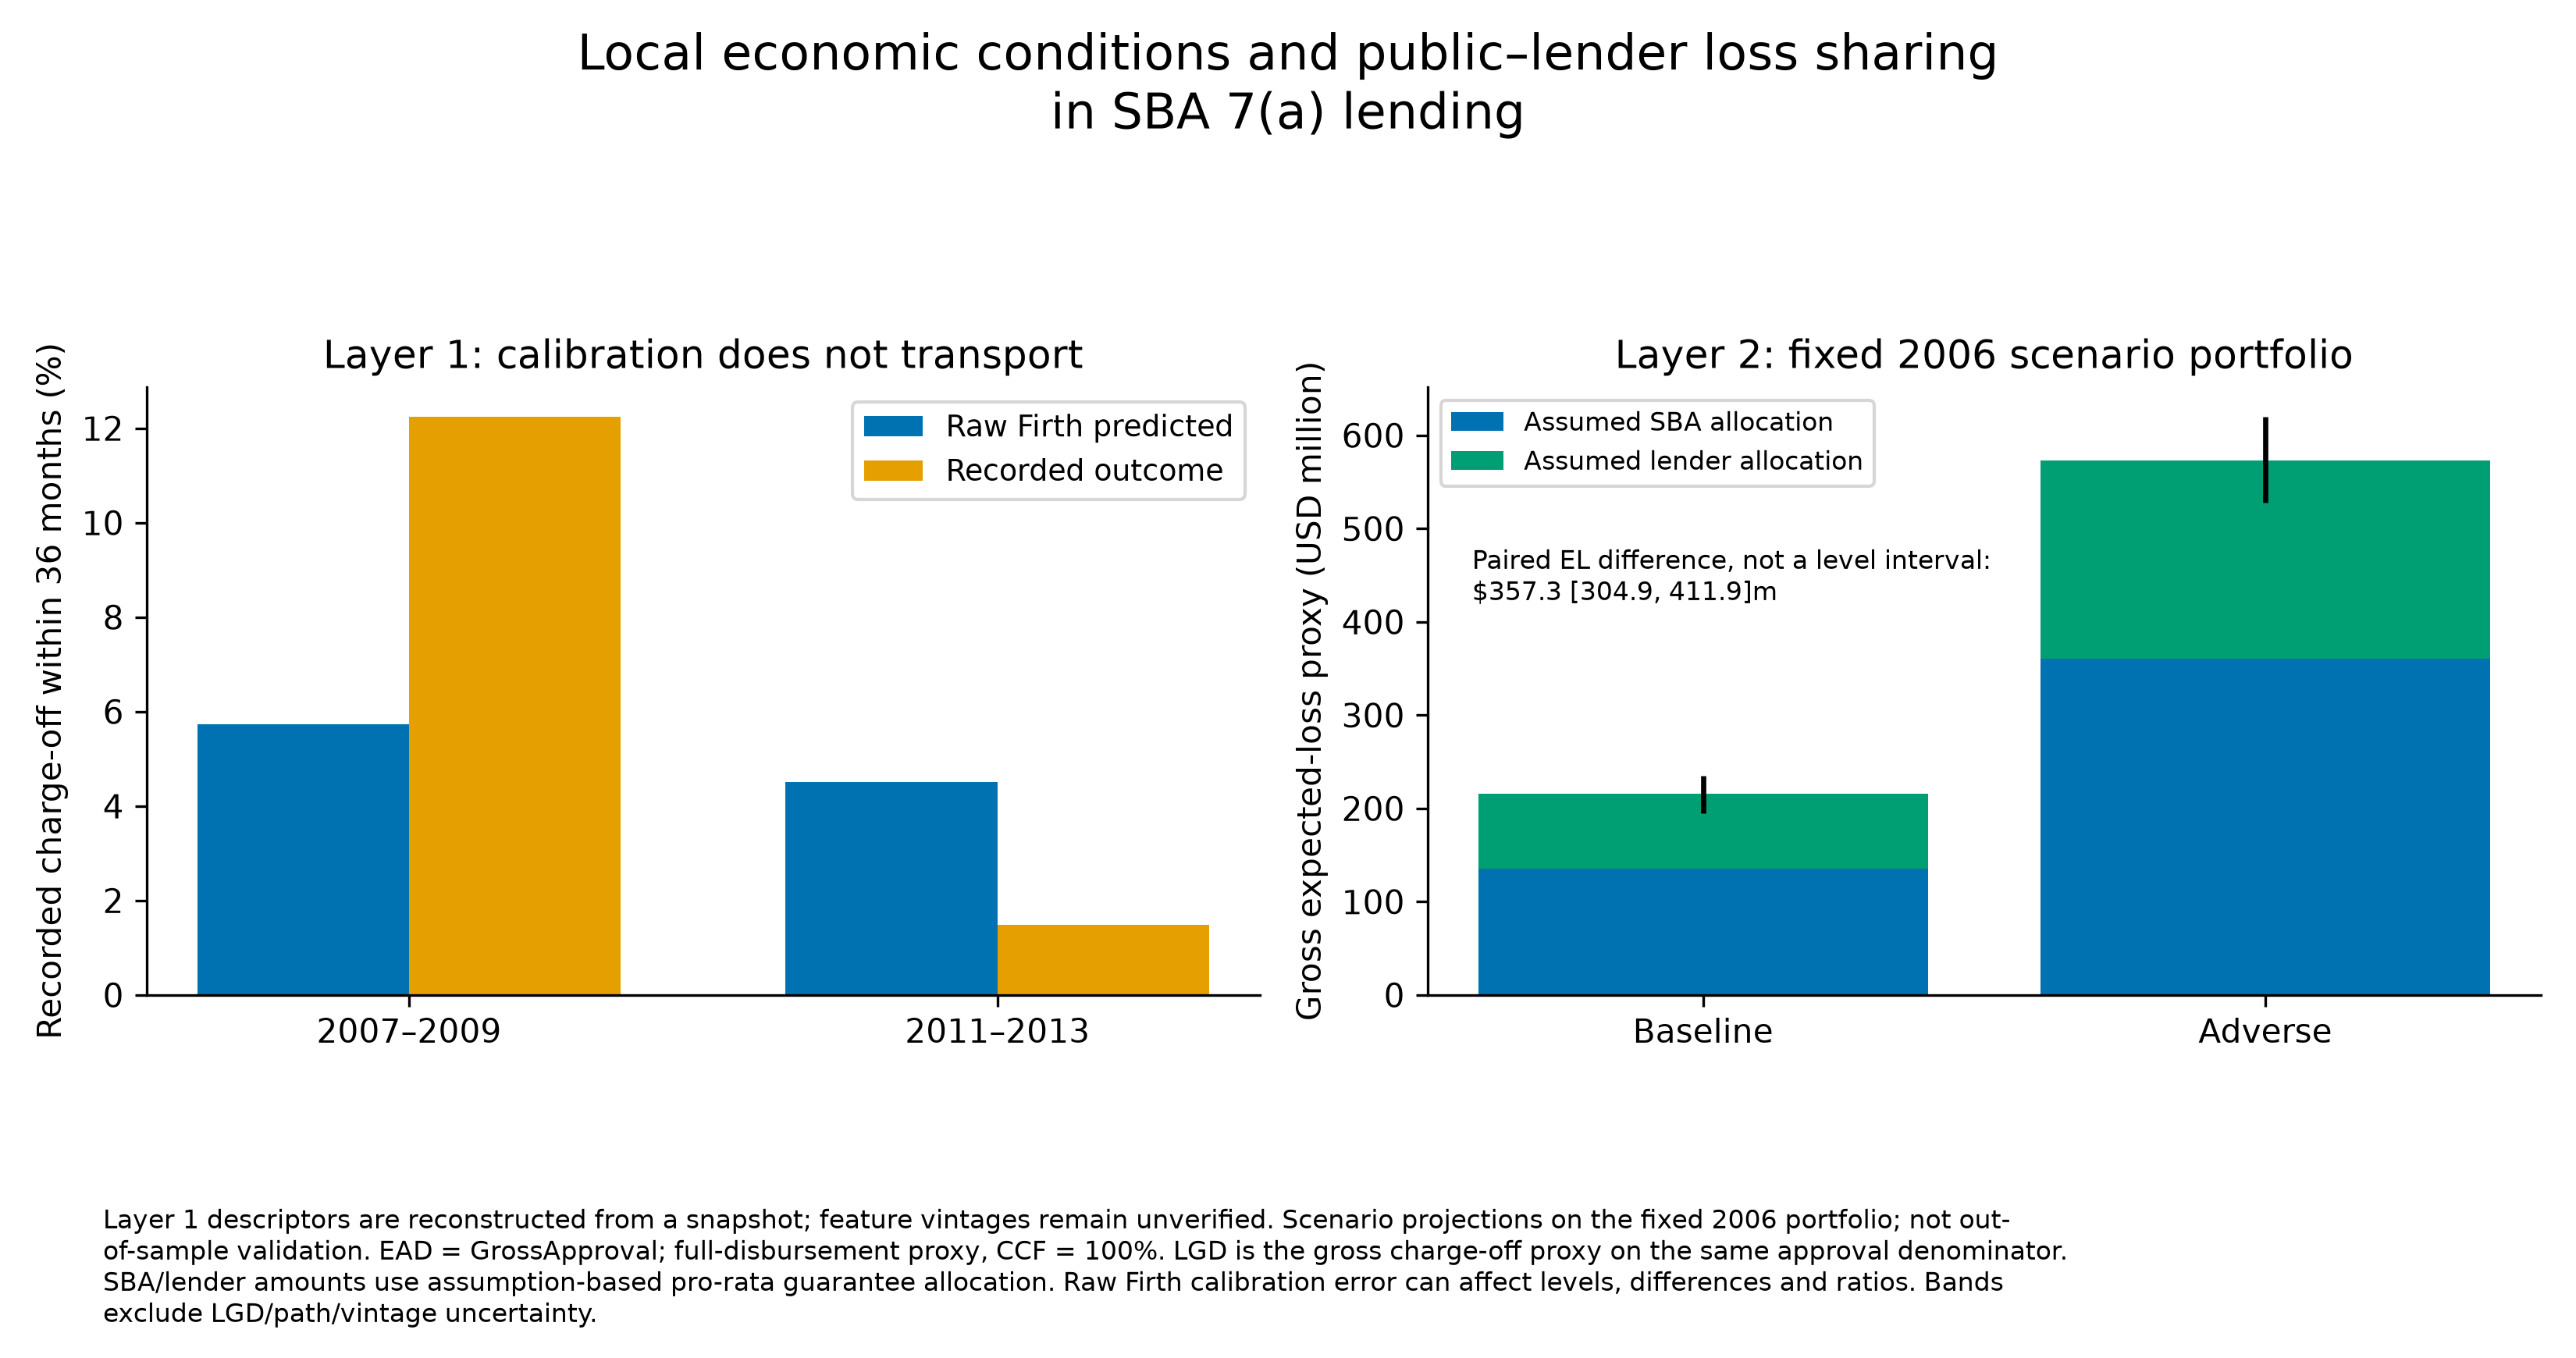

In [5]:
headline_aliases = [
    "auc_crisis", "pd_crisis", "auc_later", "pd_later",
    "pd_l2_firth", "pd_l2_tree", "tree_calibration_intercept", "tree_calibration_slope",
    "endpoint", "peak", "baseline_expected_loss_usd", "adverse_expected_loss_usd",
    "adverse_minus_baseline_expected_loss_usd_change", "baseline_sba_share", "adverse_sba_share",
]
headline = pd.DataFrame([
    {"Claim": alias, "Saved display": registry.human_display(alias)[0], "Units": registry.human_display(alias)[1]}
    for alias in headline_aliases
])
show(headline, "Registered headline quantities")
display(Image(filename=str(ROOT / "figures/g5/headline.png"), width=900))


## 4. Discrimination and temporal validation

AUC measures risk ranking; average precision depends on the outcome prevalence;
Brier score measures probability accuracy. Keep these separate from calibration.
The saved metric intervals condition on fitted models and differ from the
training-refit intervals used for Firth associations and scenarios.


In [6]:
metrics = tables["evaluation_metrics"]
validation_cohorts = ["crisis_2007_2009", "additional_cohort_2011_2013", "post_amendment_validation_2013_2014"]
main_metrics = metrics.loc[metrics["variant"].isin(["layer1", "layer2"]) & metrics["cohort"].isin(validation_cohorts)]
ranking = main_metrics.loc[main_metrics["metric"].isin(["auc", "average_precision", "brier"])]
show(ranking.pivot(index=["variant", "model", "cohort"], columns="metric", values="value").reset_index(), "Term-free model comparison")
show(ranking[["variant", "model", "cohort", "metric", "value", "lower", "upper", "bootstrap_draws", "undefined_draws"]], "Saved evaluation intervals")


**Term-free model comparison**

metric,variant,model,cohort,auc,average_precision,brier
,layer1,elasticnet_calibrated,additional_cohort_2011_2013,0.6890,0.0294,0.0163
,layer1,elasticnet_calibrated,crisis_2007_2009,0.6176,0.1526,0.1110
,layer1,elasticnet_raw,additional_cohort_2011_2013,0.6890,0.0294,0.0168
,layer1,elasticnet_raw,crisis_2007_2009,0.6176,0.1526,0.1112
,layer1,firth_raw,additional_cohort_2011_2013,0.6659,0.0272,0.0186
,layer1,firth_raw,crisis_2007_2009,0.6074,0.1522,0.1128
,layer1,lightgbm_calibrated,additional_cohort_2011_2013,0.6940,0.0281,0.0166
,layer1,lightgbm_calibrated,crisis_2007_2009,0.6169,0.1585,0.1108
,layer1,lightgbm_raw,additional_cohort_2011_2013,0.6940,0.0281,0.0176
,layer1,lightgbm_raw,crisis_2007_2009,0.6169,0.1585,0.1116


**Saved evaluation intervals**

variant,model,cohort,metric,value,lower,upper,bootstrap_draws,undefined_draws
layer1,firth_raw,crisis_2007_2009,auc,0.6074,0.5866,0.6257,999,0
layer1,firth_raw,crisis_2007_2009,average_precision,0.1522,0.1244,0.1780,999,0
layer1,firth_raw,crisis_2007_2009,brier,0.1128,0.0903,0.1338,999,0
layer1,firth_raw,additional_cohort_2011_2013,auc,0.6659,0.6379,0.6909,999,0
layer1,firth_raw,additional_cohort_2011_2013,average_precision,0.0272,0.0239,0.0306,999,0
layer1,firth_raw,additional_cohort_2011_2013,brier,0.0186,0.0169,0.0202,999,0
layer1,elasticnet_raw,crisis_2007_2009,auc,0.6176,0.5980,0.6347,999,0
layer1,elasticnet_raw,crisis_2007_2009,average_precision,0.1526,0.1264,0.1779,999,0
layer1,elasticnet_raw,crisis_2007_2009,brier,0.1112,0.0887,0.1323,999,0
layer1,elasticnet_raw,additional_cohort_2011_2013,auc,0.6890,0.6610,0.7144,999,0


## 5. Calibration: average level, intercept/slope and risk groups

Average agreement does not establish calibration across risk groups. Diagnostic
intercept and slope ideals are 0 and 1. Firth probabilities remain raw; these
diagnostics do not update them. Risk bins retain the saved training-score edges
and their unequal evaluation counts. A zero recorded rate in a nonempty bin is
a valid saved result, not missing information.


**Mean prediction versus recorded outcome (%)**

variant,model,cohort,n,events,predicted_pct,recorded_pct
layer1,firth_raw,crisis_2007_2009,181311,22212,5.7314,12.2508
layer1,firth_raw,additional_cohort_2011_2013,120002,1787,4.5043,1.4891
layer1,elasticnet_raw,crisis_2007_2009,181311,22212,5.6959,12.2508
layer1,elasticnet_raw,additional_cohort_2011_2013,120002,1787,4.4898,1.4891
layer1,elasticnet_calibrated,crisis_2007_2009,181311,22212,5.5254,12.2508
layer1,elasticnet_calibrated,additional_cohort_2011_2013,120002,1787,4.4887,1.4891
layer1,lightgbm_raw,crisis_2007_2009,181311,22212,5.5699,12.2508
layer1,lightgbm_raw,additional_cohort_2011_2013,120002,1787,4.4376,1.4891
layer1,lightgbm_calibrated,crisis_2007_2009,181311,22212,5.6120,12.2508
layer1,lightgbm_calibrated,additional_cohort_2011_2013,120002,1787,4.6267,1.4891


**Saved calibration intercept/slope and intervals**

variant,model,cohort,metric,value,lower,upper,undefined_draws
layer1,firth_raw,crisis_2007_2009,calibration_intercept,-0.9654,-1.2628,-0.6884,0
layer1,firth_raw,crisis_2007_2009,calibration_slope,0.3140,0.2561,0.3676,0
layer1,firth_raw,additional_cohort_2011_2013,calibration_intercept,-2.6663,-2.9182,-2.4399,0
layer1,firth_raw,additional_cohort_2011_2013,calibration_slope,0.4502,0.3770,0.5181,0
layer1,elasticnet_raw,crisis_2007_2009,calibration_intercept,-0.6340,-0.9392,-0.3350,0
layer1,elasticnet_raw,crisis_2007_2009,calibration_slope,0.4403,0.3721,0.5047,0
layer1,elasticnet_raw,additional_cohort_2011_2013,calibration_intercept,-2.0960,-2.3958,-1.7878,0
layer1,elasticnet_raw,additional_cohort_2011_2013,calibration_slope,0.6599,0.5697,0.7548,0
layer1,elasticnet_calibrated,crisis_2007_2009,calibration_intercept,-0.3840,-0.7142,-0.0591,0
layer1,elasticnet_calibrated,crisis_2007_2009,calibration_slope,0.5321,0.4496,0.6099,0


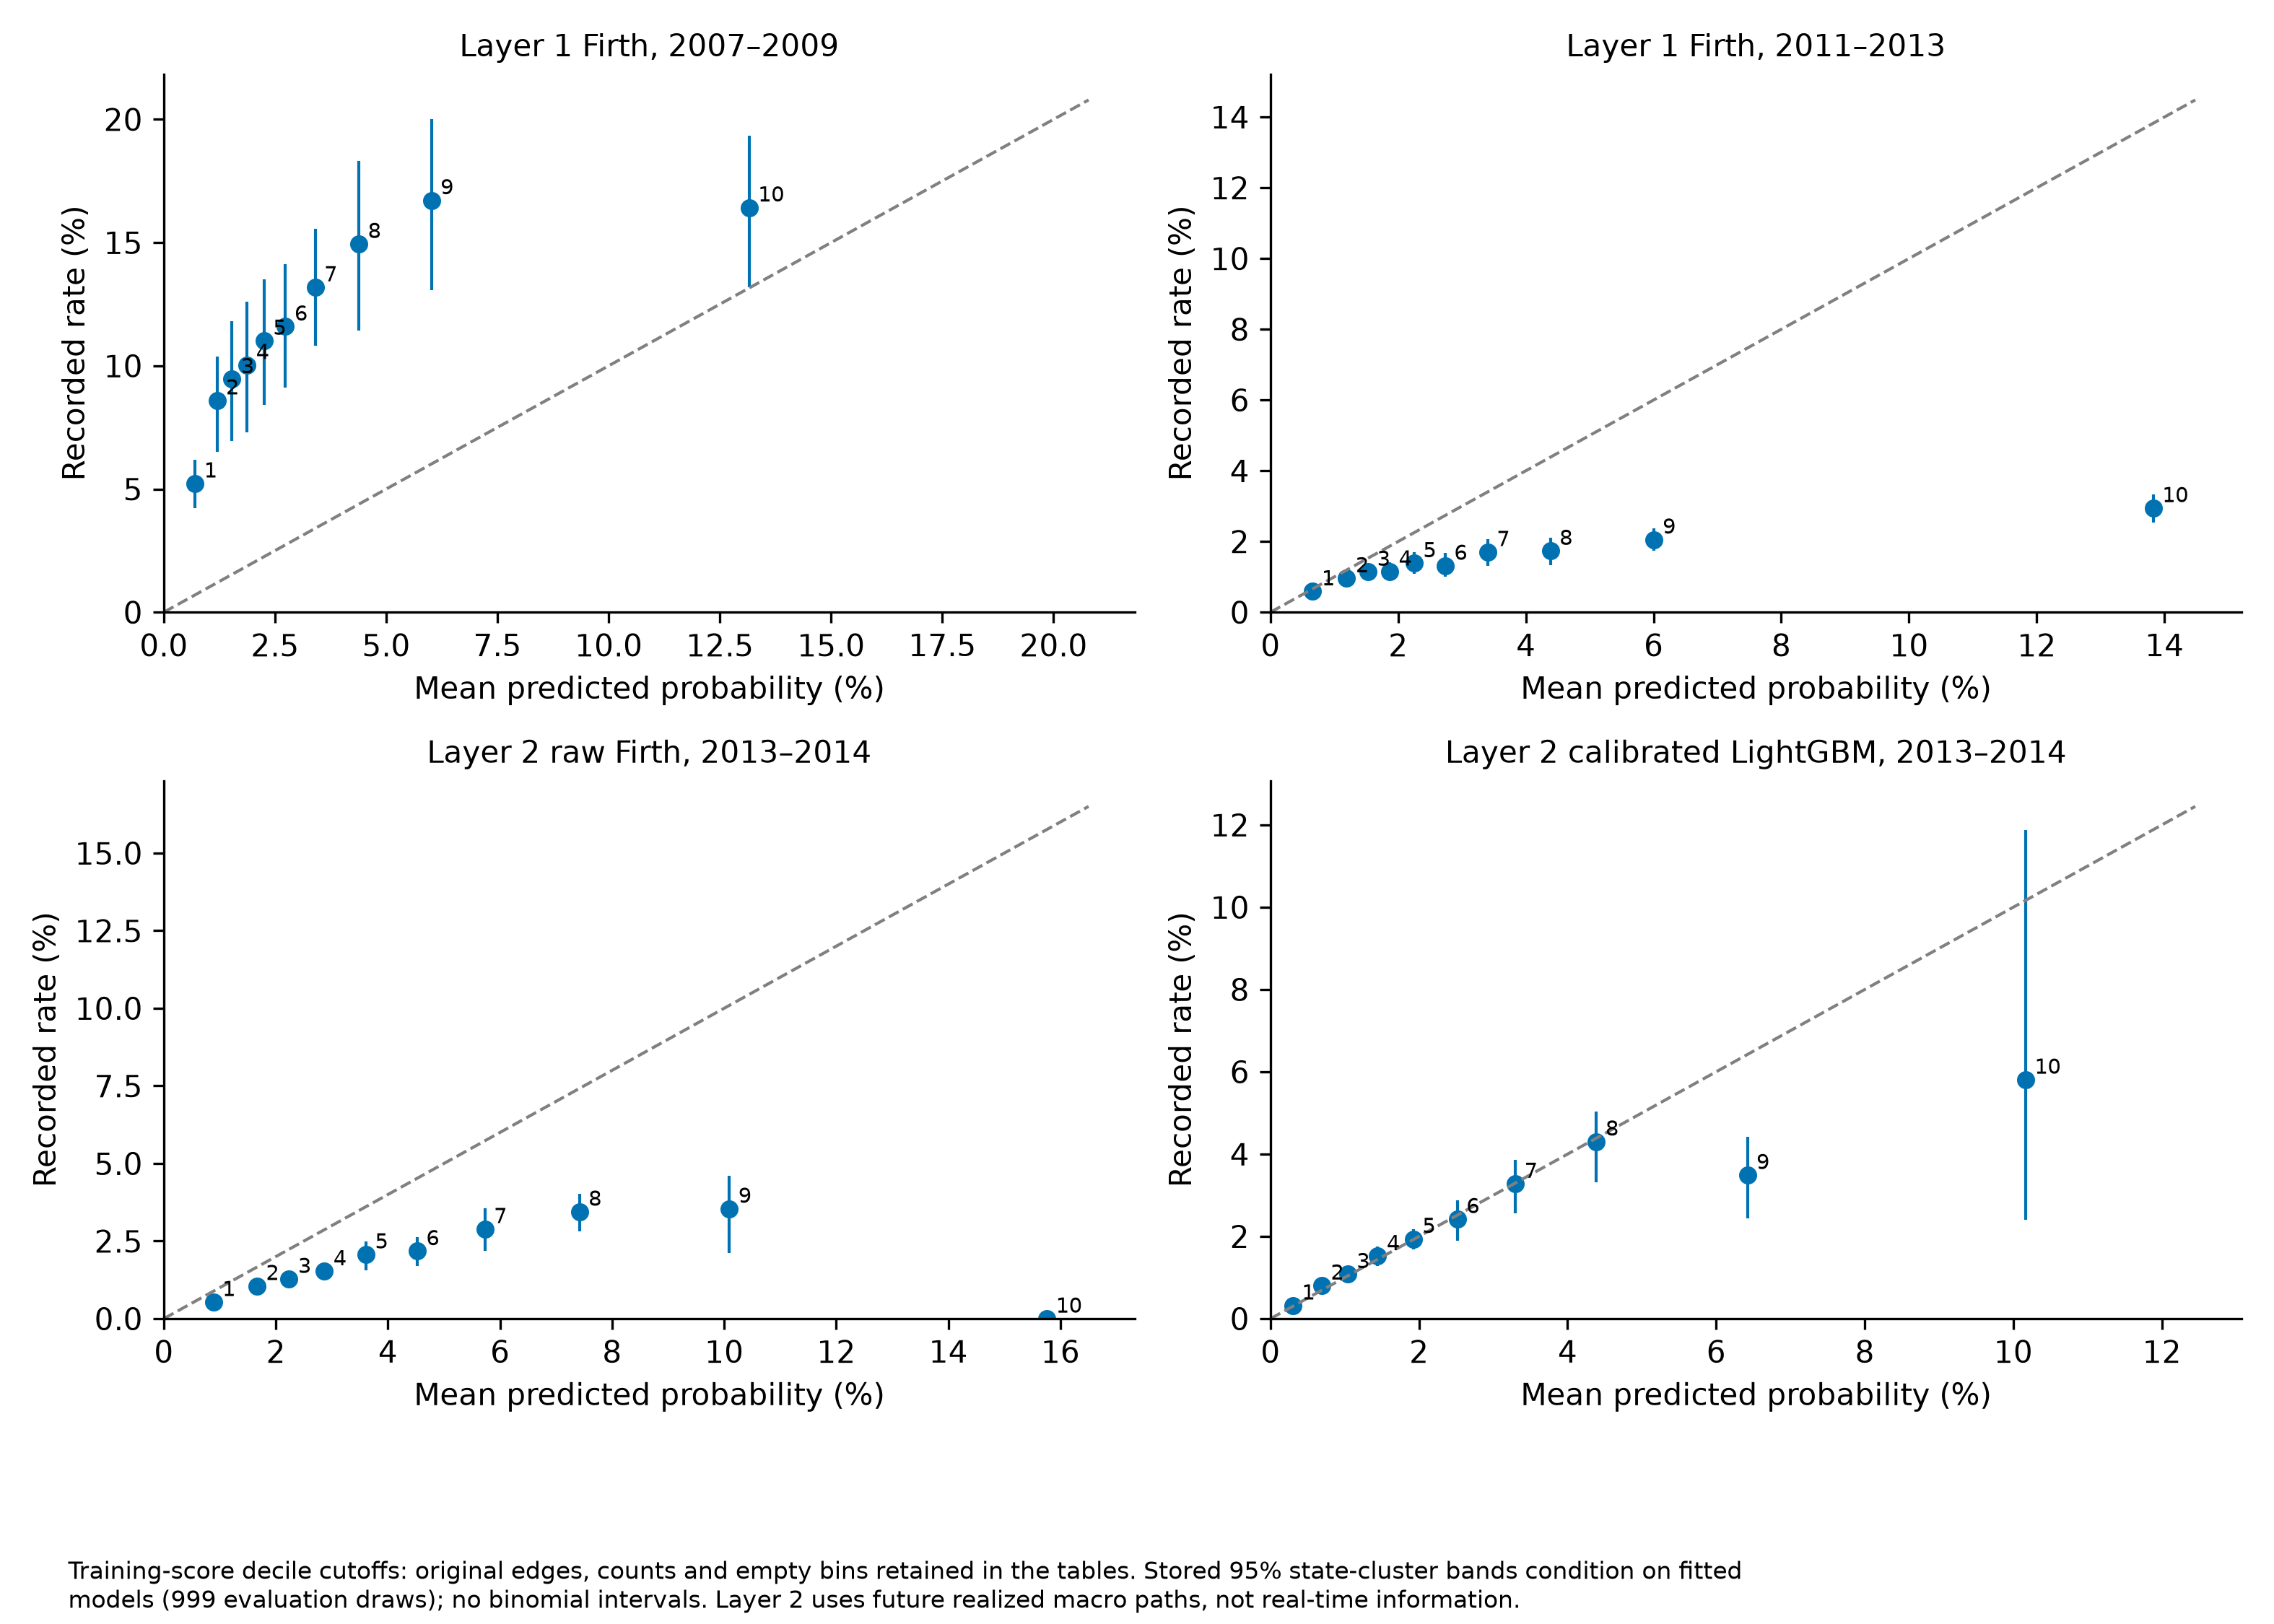

In [7]:
means = tables["calibration_means"]
main_means = means.loc[means["variant"].isin(["layer1", "layer2"]) & means["cohort"].isin(validation_cohorts)].copy()
main_means["predicted_pct"] = 100 * main_means["mean_predicted"]
main_means["recorded_pct"] = 100 * main_means["recorded_rate"]
show(main_means[["variant", "model", "cohort", "n", "events", "predicted_pct", "recorded_pct"]], "Mean prediction versus recorded outcome (%)")
show(main_metrics.loc[main_metrics["metric"].isin(["calibration_intercept", "calibration_slope"]), ["variant", "model", "cohort", "metric", "value", "lower", "upper", "undefined_draws"]], "Saved calibration intercept/slope and intervals")
display(Image(filename=str(ROOT / "figures/g5/calibration_groups.png"), width=900))


In [8]:
bins = tables["calibration_deciles"]
combinations = [
    ("layer1", "firth_raw", "crisis_2007_2009"),
    ("layer1", "firth_raw", "additional_cohort_2011_2013"),
    ("layer2", "firth_raw", "post_amendment_validation_2013_2014"),
    ("layer2", "lightgbm_calibrated", "post_amendment_validation_2013_2014"),
]
for variant, model, cohort_name in combinations:
    block = select(bins, variant=variant, model=model, cohort=cohort_name)
    assert len(block) == 10 and (block["n"] > 0).all()
    show(block[["bin", "lower_edge", "upper_edge", "n", "predicted_pd", "recorded_rate", "lower", "upper", "undefined_draws"]], f"Saved risk groups: {variant} / {model} / {cohort_name}")


**Saved risk groups: layer1 / firth_raw / crisis_2007_2009**

bin,lower_edge,upper_edge,n,predicted_pd,recorded_rate,lower,upper,undefined_draws
1,-inf,0.0103,31377,0.0070,0.0522,0.0422,0.0620,0
2,0.0103,0.0137,16171,0.0120,0.0860,0.0651,0.1037,0
3,0.0137,0.0170,12543,0.0153,0.0946,0.0695,0.1182,0
4,0.0170,0.0206,10090,0.0187,0.1003,0.0730,0.1260,0
5,0.0206,0.0248,8824,0.0226,0.1102,0.0840,0.1351,0
6,0.0248,0.0303,8290,0.0274,0.1159,0.0911,0.1412,0
7,0.0303,0.0381,8624,0.0340,0.1318,0.1083,0.1556,0
8,0.0381,0.0497,11130,0.0439,0.1494,0.1143,0.1832,0
9,0.0497,0.0710,19353,0.0602,0.1672,0.1308,0.2000,0
10,0.0710,inf,54909,0.1316,0.1642,0.1319,0.1934,0


**Saved risk groups: layer1 / firth_raw / additional_cohort_2011_2013**

bin,lower_edge,upper_edge,n,predicted_pd,recorded_rate,lower,upper,undefined_draws
1,-inf,0.0103,33943,0.0066,0.0059,0.0047,0.0072,0
2,0.0103,0.0137,13447,0.0119,0.0096,0.0077,0.0119,0
3,0.0137,0.0170,9097,0.0153,0.0114,0.0092,0.0137,0
4,0.0170,0.0206,6780,0.0187,0.0115,0.0094,0.0142,0
5,0.0206,0.0248,5490,0.0225,0.0138,0.0109,0.0171,0
6,0.0248,0.0303,4725,0.0274,0.0131,0.0100,0.0168,0
7,0.0303,0.0381,4819,0.0340,0.0170,0.0131,0.0208,0
8,0.0381,0.0497,6398,0.0438,0.0173,0.0134,0.0210,0
9,0.0497,0.0710,10525,0.0600,0.0205,0.0174,0.0236,0
10,0.0710,inf,24778,0.1382,0.0294,0.0253,0.0334,0


**Saved risk groups: layer2 / firth_raw / post_amendment_validation_2013_2014**

bin,lower_edge,upper_edge,n,predicted_pd,recorded_rate,lower,upper,undefined_draws
1,-inf,0.0140,24535,0.0089,0.0053,0.0043,0.0067,0
2,0.0140,0.0195,12067,0.0166,0.0105,0.0086,0.0125,0
3,0.0195,0.0253,10790,0.0224,0.0128,0.0104,0.0150,0
4,0.0253,0.0322,10228,0.0287,0.0153,0.0128,0.0172,0
5,0.0322,0.0403,9714,0.0361,0.0207,0.0157,0.0248,0
6,0.0403,0.0510,8740,0.0452,0.0217,0.0169,0.0262,0
7,0.0510,0.0655,6411,0.0573,0.0289,0.0219,0.0356,0
8,0.0655,0.0885,3773,0.0742,0.0345,0.0281,0.0402,0
9,0.0885,0.1370,876,0.1009,0.0354,0.0213,0.0460,0
10,0.1370,inf,22,0.1576,0.0000,0.0000,0.0000,0


**Saved risk groups: layer2 / lightgbm_calibrated / post_amendment_validation_2013_2014**

bin,lower_edge,upper_edge,n,predicted_pd,recorded_rate,lower,upper,undefined_draws
1,-inf,0.0054,23805,0.0030,0.0032,0.0025,0.0041,0
2,0.0054,0.0086,10188,0.0069,0.0080,0.0060,0.0097,0
3,0.0086,0.0123,10346,0.0104,0.0108,0.0088,0.0128,0
4,0.0123,0.0167,10867,0.0144,0.0152,0.0128,0.0176,0
5,0.0167,0.0221,11818,0.0192,0.0194,0.0169,0.0218,0
6,0.0221,0.0289,8848,0.0252,0.0242,0.0190,0.0288,0
7,0.0289,0.0383,6532,0.0330,0.0328,0.0256,0.0385,0
8,0.0383,0.0533,3393,0.0439,0.0430,0.0332,0.0503,0
9,0.0533,0.0879,1204,0.0642,0.0349,0.0244,0.0443,0
10,0.0879,inf,155,0.1017,0.0581,0.0241,0.1187,0


## 6. Conditional macro associations

Endpoint unemployment change is **u at month +36 minus u at the disbursement
month**. Peak change is **max(u month − u start)** within the window; it can capture
an increase followed by recovery. These are separately estimated specifications.
The +1 pp conditional contrast is a finite probability change on the fixed 2006
portfolio, not a causal effect or an automatic derivative.

Saved macro variables: `u0` is starting unemployment in percent, `du` and
`peak_du` are unemployment changes in percentage points, `h0` is starting
four-quarter HPI growth as 100 × log(HPI / HPI one year earlier), and `dh` is
the 36-month HPI log change as 100 × log(HPI end / HPI start).

State effects do not identify unemployment, housing or guarantee coefficients
causally. Numeric logit coefficients are on training-standardized feature scales;
saved average associations use their stated native units/contrasts.


In [9]:
macro = tables["firth_macro_associations"]
main_macro = macro.loc[macro["variant"].isin(["layer2", "layer2_peak"]) & macro["group"].eq("overall")]
show(main_macro[["variant", "feature", "change", "value", "lower", "upper", "n", "effective_interval_draws", "interpretation"]], "Endpoint and peak unemployment contrasts (probability pp)")
associations = tables["firth_average_associations"]
important = associations.loc[associations["variant"].isin(["layer1", "layer2"]) & associations["feature"].isin(["log_approval", "guarantee_share", "log_jobs", "u0", "du", "h0", "dh", "year_trend"])]
show(important[["variant", "feature", "value", "lower", "upper", "contrast", "effective_interval_draws"]], "Selected saved average associations (not causal)")
show(macro.loc[macro["variant"].isin(["layer2", "layer2_peak"]) & macro["group"].eq("loan_type"), ["variant", "feature", "group_value", "value", "lower", "upper", "effective_interval_draws"]], "Loan-type conditional contrasts")


**Endpoint and peak unemployment contrasts (probability pp)**

variant,feature,change,value,lower,upper,n,effective_interval_draws,interpretation
layer2,du,+1 percentage point du,0.5349,0.2655,0.7718,89002,198,"conditional finite-change association, not causal"
layer2_peak,peak_du,+1 percentage point peak_du,0.6790,0.4389,0.9328,89002,198,"conditional finite-change association, not causal"


**Selected saved average associations (not causal)**

variant,feature,value,lower,upper,contrast,effective_interval_draws
layer1,log_approval,-1.2801,-1.5093,-1.1394,derivative per unit of native feature (log variables remain log units),196
layer1,guarantee_share,-4.7519,-6.4721,-3.4754,derivative per unit of native feature (log variables remain log units),196
layer1,log_jobs,-0.0520,-0.2794,0.1576,derivative per unit of native feature (log variables remain log units),196
layer2,log_approval,-2.1463,-2.5126,-1.7264,derivative per unit of native feature (log variables remain log units),198
layer2,guarantee_share,1.9451,-3.8125,9.1071,derivative per unit of native feature (log variables remain log units),198
layer2,log_jobs,0.5423,0.3911,0.6889,derivative per unit of native feature (log variables remain log units),198
layer2,u0,-0.5354,-1.1141,0.0371,derivative per unit of native feature (log variables remain log units),198
layer2,du,0.5239,0.2627,0.7495,derivative per unit of native feature (log variables remain log units),198
layer2,h0,-0.2083,-0.2371,-0.1651,derivative per unit of native feature (log variables remain log units),198
layer2,dh,-0.0941,-0.1322,-0.0751,derivative per unit of native feature (log variables remain log units),198


**Loan-type conditional contrasts**

variant,feature,group_value,value,lower,upper,effective_interval_draws
layer2,du,revolving,0.6087,0.3064,0.8680,198
layer2,du,term,0.4819,0.2413,0.7101,198
layer2_peak,peak_du,revolving,0.7730,0.5002,1.0600,198
layer2_peak,peak_du,term,0.6114,0.3861,0.8415,198


## 7. Stress scenarios and public–lender loss accounting

The 2006 reference portfolio is a **scenario portfolio, not an out-of-sample
validation test**. Paths are stipulated. Display their context using
`macro_information_context`; the inherited validation label in another source
column is not a scenario interpretation.

**EAD = GrossApproval, CCF = 100%, full-disbursement proxy.** LGD is gross charge-off
amount divided by that same approval proxy, not net-of-recovery LGD. Expected loss
is summed as PD × EAD × LGD. Allocation uses each loan's guaranteed-approval share
pro rata for SBA and its complement for lenders. These are loss proxies, not
observed guarantee payouts or measured fiscal costs. Scenario PDs reweight loans,
so aggregate SBA shares need not be constant.

Saved paired-difference intervals use paired draws; do not subtract marginal
interval endpoints. Probability miscalibration can affect levels, differences
and ratios. Intervals hold the portfolio, macro paths, EAD and LGD assumptions fixed.


In [10]:
paths = tables["scenario_paths"]
show(paths.groupby("scenario")[["u0", "du", "peak_du", "h0", "dh"]].agg(["min", "max"]).reset_index(), "Stipulated state-path ranges (descriptive summary)")
show(tables["loss_population"], "PD and loss accounting population")
stress = tables["firth_stress"]
overall = select(stress, variant="layer2", lgd_variant="primary", group="overall")
main_stress = overall.loc[overall["metric"].isin(["pd", "expected_loss_usd", "sba_loss_usd", "lender_loss_usd", "pd_change_pp", "expected_loss_usd_change", "sba_loss_usd_change", "lender_loss_usd_change"])].copy()
main_stress["display_units"] = np.where(main_stress["metric"].str.contains("loss_usd"), "USD millions", np.where(main_stress["metric"].eq("pd"), "PD percent", "probability pp"))
scale = np.where(main_stress["metric"].str.contains("loss_usd"), 1e-6, np.where(main_stress["metric"].eq("pd"), 100, 1))
for field in ["value", "lower", "upper"]:
    main_stress[field] = main_stress[field] * scale
show(main_stress[["scenario", "metric", "value", "lower", "upper", "display_units", "effective_interval_draws"]], "Primary Firth scenario PD and loss proxies")
assert overall["macro_information_context"].str.contains("scenario portfolio").all()


**Stipulated state-path ranges (descriptive summary)**

**PD and loss accounting population**

reference_n,valid_loss_n,excluded_invalid_share_n,loss_accounting,reference_role
89002,89002,0,"EAD = GrossApproval, full-disbursement proxy, CCF = 100%; gross charge-off LGD proxy; assumption-based pro-rata guarantee allocation.","Fixed 2006 scenario portfolio; included in Layer 2 estimation, not OOS validation"


**Primary Firth scenario PD and loss proxies**

scenario,metric,value,lower,upper,display_units,effective_interval_draws
baseline,pd,5.1646,4.6095,5.7910,PD percent,198
baseline,expected_loss_usd,215.5766,194.8548,234.9931,USD millions,198
baseline,sba_loss_usd,135.3763,123.9593,146.8127,USD millions,198
baseline,lender_loss_usd,80.2003,70.7884,88.6933,USD millions,198
adverse,pd,12.7840,12.4643,13.3424,PD percent,198
adverse,expected_loss_usd,572.8728,528.2050,620.2820,USD millions,198
adverse,sba_loss_usd,360.7103,328.1919,393.9042,USD millions,198
adverse,lender_loss_usd,212.1626,199.4887,227.0331,USD millions,198
adverse_minus_baseline,pd_change_pp,7.6194,6.7716,8.6173,probability pp,198
adverse_minus_baseline,expected_loss_usd_change,357.2962,304.8572,411.9015,USD millions,198


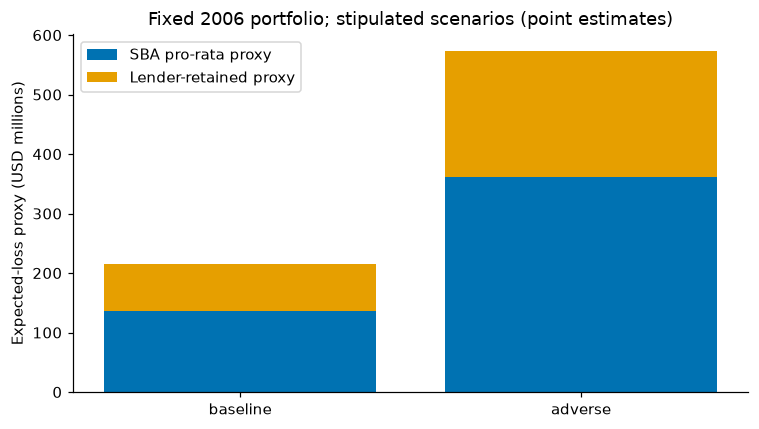

**Scenario-dependent pro-rata allocation (dollar columns in USD)**

metric,scenario,expected_loss_usd,sba_loss_usd,lender_loss_usd,sba_share_pct,lender_share_pct
,baseline,"215,576,590.2728","135,376,308.1581","80,200,282.1147",62.7973,37.2027
,adverse,"572,872,825.8928","360,710,273.4397","212,162,552.4531",62.9652,37.0348


In [11]:
scenarios = ["baseline", "adverse"]
allocation = overall.loc[overall["scenario"].isin(scenarios)].pivot(index="scenario", columns="metric", values="value").reindex(scenarios)
assert np.allclose(allocation["expected_loss_usd"], allocation["sba_loss_usd"] + allocation["lender_loss_usd"])
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(scenarios, allocation["sba_loss_usd"] / 1e6, label="SBA pro-rata proxy", color="#0072B2")
ax.bar(scenarios, allocation["lender_loss_usd"] / 1e6, bottom=allocation["sba_loss_usd"] / 1e6, label="Lender-retained proxy", color="#E69F00")
ax.set(ylabel="Expected-loss proxy (USD millions)", title="Fixed 2006 portfolio; stipulated scenarios (point estimates)")
ax.legend()
fig.tight_layout()
plt.show()
shares = allocation[["expected_loss_usd", "sba_loss_usd", "lender_loss_usd"]].copy()
shares["sba_share_pct"] = 100 * shares["sba_loss_usd"] / shares["expected_loss_usd"]
shares["lender_share_pct"] = 100 - shares["sba_share_pct"]
show(shares.reset_index(), "Scenario-dependent pro-rata allocation (dollar columns in USD)")


## 8. Predeclared sensitivities and subgroup results

Endpoint versus peak unemployment, primary versus capped/downturn LGD, and
with-Term variants remain separately labelled. With-Term results do not replace
the Term-free headline. Downturn LGD uses only training charge-offs from the
1991 and 2000–2001 disbursement cohorts, with the fixed small-cell pooling rule.
Revolving lines are separate; 100% utilization is an assumption.


In [12]:
sensitivity = stress.loc[stress["group"].eq("overall") & stress["metric"].isin(["pd", "expected_loss_usd", "expected_loss_usd_change"])].copy()
sensitivity["units"] = np.where(sensitivity["metric"].eq("pd"), "PD percent", "USD millions")
sensitivity["display_value"] = sensitivity["value"] * np.where(sensitivity["metric"].eq("pd"), 100, 1e-6)
sensitivity["display_lower"] = sensitivity["lower"] * np.where(sensitivity["metric"].eq("pd"), 100, 1e-6)
sensitivity["display_upper"] = sensitivity["upper"] * np.where(sensitivity["metric"].eq("pd"), 100, 1e-6)
show(sensitivity[["variant", "lgd_variant", "scenario", "metric", "display_value", "display_lower", "display_upper", "units", "effective_interval_draws"]], "All overall Firth scenario sensitivities")
lgd = pd.concat([tables["lgd_primary"], tables["lgd_capped"], tables["lgd_downturn"]], ignore_index=True)
show(lgd[["variant", "loan_type", "size_band", "cohorts", "valid_cell_n", "pool", "pooled_n", "lgd_proxy", "ratios_above_one"]], "LGD proxy cells and pooling")


**All overall Firth scenario sensitivities**

variant,lgd_variant,scenario,metric,display_value,display_lower,display_upper,units,effective_interval_draws
layer2,primary,baseline,pd,5.1646,4.6095,5.7910,PD percent,198
layer2,primary,baseline,expected_loss_usd,215.5766,194.8548,234.9931,USD millions,198
layer2,primary,adverse,pd,12.7840,12.4643,13.3424,PD percent,198
layer2,primary,adverse,expected_loss_usd,572.8728,528.2050,620.2820,USD millions,198
layer2,capped,adverse,pd,12.7840,12.4643,13.3424,PD percent,198
layer2,capped,adverse,expected_loss_usd,568.4485,524.0487,615.5946,USD millions,198
layer2,downturn,adverse,pd,12.7840,12.4643,13.3424,PD percent,198
layer2,downturn,adverse,expected_loss_usd,612.6058,561.0862,666.2884,USD millions,198
layer2,primary,adverse_minus_baseline,expected_loss_usd_change,357.2962,304.8572,411.9015,USD millions,198
layer2_term,primary,baseline,pd,5.3306,4.7712,5.8347,PD percent,197


**LGD proxy cells and pooling**

variant,loan_type,size_band,cohorts,valid_cell_n,pool,pooled_n,lgd_proxy,ratios_above_one
primary,term,<=150k,1991-2002,10345,cell,10345,0.7362,315
primary,term,150k-350k,1991-2002,1687,cell,1687,0.6745,59
primary,term,350k-1m,1991-2002,808,cell,808,0.6191,24
primary,term,>1m,1991-2002,81,cell,81,0.5083,1
primary,revolving,<=150k,1991-2002,1059,cell,1059,0.8987,31
primary,revolving,150k-350k,1991-2002,12,loan_type,1082,0.8374,31
primary,revolving,350k-1m,1991-2002,10,loan_type,1082,0.8374,31
primary,revolving,>1m,1991-2002,1,loan_type,1082,0.8374,31
primary,unknown,<=150k,1991-2002,0,overall_selected_training_cohorts,14003,0.6785,430
primary,unknown,150k-350k,1991-2002,0,overall_selected_training_cohorts,14003,0.6785,430


In [13]:
loan_type_losses = stress.loc[stress["variant"].eq("layer2") & stress["lgd_variant"].eq("primary") & stress["group"].eq("loan_type") & stress["metric"].isin(["pd", "expected_loss_usd", "sba_loss_usd", "lender_loss_usd"])]
show(loan_type_losses[["scenario", "group_value", "metric", "value", "lower", "upper", "pd_n", "loss_n", "effective_interval_draws"]], "Term versus revolving: saved values (PD fraction; losses USD)")
subgroup_results = stress.loc[stress["variant"].eq("layer2") & stress["lgd_variant"].eq("primary") & stress["group"].isin(["size_band", "naics2", "age_group", "maturity_group"])]
show(subgroup_results[["scenario", "group", "group_value", "metric", "value", "lower", "upper", "pd_n", "effective_interval_draws"]], "All other primary subgroup results: available as subgroup_results", rows=18)
show(tables["paired_term_differences"], "Saved paired with-Term differences: qualified sensitivity", rows=12)
benchmark_stress = tables["benchmark_stress_point"]
show(benchmark_stress.loc[benchmark_stress["variant"].eq("layer2") & benchmark_stress["lgd_variant"].eq("primary") & benchmark_stress["group"].eq("overall")], "Fixed-tree stress robustness: point estimates only", rows=16)


**Term versus revolving: saved values (PD fraction; losses USD)**

scenario,group_value,metric,value,lower,upper,pd_n,loss_n,effective_interval_draws
baseline,revolving,pd,0.0556,0.0490,0.0619,37202,37202,198
baseline,revolving,expected_loss_usd,"68,598,936.1212","59,847,054.0267","76,112,873.1168",37202,37202,198
baseline,revolving,sba_loss_usd,"35,484,452.4275","31,039,855.0955","39,143,904.8500",37202,37202,198
baseline,revolving,lender_loss_usd,"33,114,483.6937","28,811,770.4309","36,932,487.3428",37202,37202,198
baseline,term,pd,0.0488,0.0435,0.0552,51800,51800,198
baseline,term,expected_loss_usd,"146,977,654.1516","133,423,403.4412","159,135,132.0688",51800,51800,198
baseline,term,sba_loss_usd,"99,891,855.7306","90,528,563.2094","108,012,327.6362",51800,51800,198
baseline,term,lender_loss_usd,"47,085,798.4210","41,805,000.1786","52,115,369.9448",51800,51800,198
adverse,revolving,pd,0.1452,0.1383,0.1547,37202,37202,198
adverse,revolving,expected_loss_usd,"182,564,501.8597","170,316,955.9160","198,793,652.7084",37202,37202,198


**All other primary subgroup results: available as subgroup_results**

scenario,group,group_value,metric,value,lower,upper,pd_n,effective_interval_draws
baseline,size_band,150k-350k,pd,0.0241,0.0220,0.0261,9230,198
baseline,size_band,150k-350k,expected_loss_usd,"37,232,155.7371","33,904,641.2869","40,450,741.3082",9230,198
baseline,size_band,150k-350k,sba_loss_usd,"23,882,438.4113","21,691,525.3005","25,694,527.5482",9230,198
baseline,size_band,150k-350k,lender_loss_usd,"13,349,717.3258","11,850,333.1591","14,581,050.0145",9230,198
baseline,size_band,150k-350k,loss_rate,0.0165,0.0150,0.0179,9230,198
baseline,size_band,350k-1m,pd,0.0146,0.0131,0.0161,6808,198
baseline,size_band,350k-1m,expected_loss_usd,"36,113,706.8691","32,483,957.5611","39,830,490.6731",6808,198
baseline,size_band,350k-1m,sba_loss_usd,"27,124,976.3195","24,390,878.0139","29,919,122.9834",6808,198
baseline,size_band,350k-1m,lender_loss_usd,"8,988,730.5496","8,093,263.7422","9,911,367.6897",6808,198
...,...,...,...,...,...,...,...,...


**Saved paired with-Term differences: qualified sensitivity**

comparison,model,cohort,metric,difference,lower,upper,draws,undefined_draws,interval,layer_interpretation
layer1_term minus layer1,firth_raw,crisis_2007_2009,auc,0.0299,0.0242,0.0342,999,0,"paired state-cluster, conditional on frozen fitted models; not Firth training-refit interval",Approval-descriptor prediction
layer1_term minus layer1,firth_raw,crisis_2007_2009,average_precision,0.0176,0.0116,0.0207,999,0,"paired state-cluster, conditional on frozen fitted models; not Firth training-refit interval",Approval-descriptor prediction
layer1_term minus layer1,firth_raw,crisis_2007_2009,brier,0.0000,-0.0005,0.0005,999,0,"paired state-cluster, conditional on frozen fitted models; not Firth training-refit interval",Approval-descriptor prediction
layer1_term minus layer1,firth_raw,crisis_2007_2009,calibration_intercept,0.4350,0.3746,0.4758,999,0,"paired state-cluster, conditional on frozen fitted models; not Firth training-refit interval",Approval-descriptor prediction
layer1_term minus layer1,firth_raw,crisis_2007_2009,calibration_slope,0.0986,0.0807,0.1109,999,0,"paired state-cluster, conditional on frozen fitted models; not Firth training-refit interval",Approval-descriptor prediction
layer1_term minus layer1,firth_raw,additional_cohort_2011_2013,auc,0.0427,0.0352,0.0511,999,0,"paired state-cluster, conditional on frozen fitted models; not Firth training-refit interval",Approval-descriptor prediction
...,...,...,...,...,...,...,...,...,...,...
layer2_term minus layer2,lightgbm_raw,post_amendment_validation_2013_2014,calibration_slope,0.1230,0.0584,0.2099,999,0,"paired state-cluster, conditional on frozen fitted models; not Firth training-refit interval",Retrospective conditional validation using realized macro paths.
layer2_term minus layer2,lightgbm_calibrated,post_amendment_validation_2013_2014,auc,0.2540,0.2338,0.2798,999,0,"paired state-cluster, conditional on frozen fitted models; not Firth training-refit interval",Retrospective conditional validation using realized macro paths.
layer2_term minus layer2,lightgbm_calibrated,post_amendment_validation_2013_2014,average_precision,0.3468,0.2738,0.3966,999,0,"paired state-cluster, conditional on frozen fitted models; not Firth training-refit interval",Retrospective conditional validation using realized macro paths.


**Fixed-tree stress robustness: point estimates only**

variant,model,scenario,lgd_variant,group,group_value,metric,value,interval,loss_accounting,layer_interpretation,macro_information_context,specification_role
layer2,lightgbm_raw,baseline,primary,overall,all,pd,0.0548,none: secondary fixed-tree point estimate,"EAD = GrossApproval, full-disbursement proxy, CCF = 100%; gross charge-off LGD proxy; assumption-based pro-rata guarantee allocation.",Retrospective conditional validation using realized macro paths.,Stipulated baseline/adverse paths; fixed 2006 scenario portfolio; not out-of-sample realized-path validation,Term-free primary specification
layer2,lightgbm_raw,baseline,primary,overall,all,expected_loss_usd,"185,783,159.7403",none: secondary fixed-tree point estimate,"EAD = GrossApproval, full-disbursement proxy, CCF = 100%; gross charge-off LGD proxy; assumption-based pro-rata guarantee allocation.",Retrospective conditional validation using realized macro paths.,Stipulated baseline/adverse paths; fixed 2006 scenario portfolio; not out-of-sample realized-path validation,Term-free primary specification
layer2,lightgbm_raw,baseline,primary,overall,all,sba_loss_usd,"113,524,164.4811",none: secondary fixed-tree point estimate,"EAD = GrossApproval, full-disbursement proxy, CCF = 100%; gross charge-off LGD proxy; assumption-based pro-rata guarantee allocation.",Retrospective conditional validation using realized macro paths.,Stipulated baseline/adverse paths; fixed 2006 scenario portfolio; not out-of-sample realized-path validation,Term-free primary specification
layer2,lightgbm_raw,baseline,primary,overall,all,lender_loss_usd,"72,258,995.2593",none: secondary fixed-tree point estimate,"EAD = GrossApproval, full-disbursement proxy, CCF = 100%; gross charge-off LGD proxy; assumption-based pro-rata guarantee allocation.",Retrospective conditional validation using realized macro paths.,Stipulated baseline/adverse paths; fixed 2006 scenario portfolio; not out-of-sample realized-path validation,Term-free primary specification
layer2,lightgbm_raw,adverse,primary,overall,all,pd,0.1026,none: secondary fixed-tree point estimate,"EAD = GrossApproval, full-disbursement proxy, CCF = 100%; gross charge-off LGD proxy; assumption-based pro-rata guarantee allocation.",Retrospective conditional validation using realized macro paths.,Stipulated baseline/adverse paths; fixed 2006 scenario portfolio; not out-of-sample realized-path validation,Term-free primary specification
layer2,lightgbm_raw,adverse,primary,overall,all,expected_loss_usd,"436,303,565.2476",none: secondary fixed-tree point estimate,"EAD = GrossApproval, full-disbursement proxy, CCF = 100%; gross charge-off LGD proxy; assumption-based pro-rata guarantee allocation.",Retrospective conditional validation using realized macro paths.,Stipulated baseline/adverse paths; fixed 2006 scenario portfolio; not out-of-sample realized-path validation,Term-free primary specification
layer2,lightgbm_raw,adverse,primary,overall,all,sba_loss_usd,"271,134,858.7906",none: secondary fixed-tree point estimate,"EAD = GrossApproval, full-disbursement proxy, CCF = 100%; gross charge-off LGD proxy; assumption-based pro-rata guarantee allocation.",Retrospective conditional validation using realized macro paths.,Stipulated baseline/adverse paths; fixed 2006 scenario portfolio; not out-of-sample realized-path validation,Term-free primary specification
layer2,lightgbm_raw,adverse,primary,overall,all,lender_loss_usd,"165,168,706.4569",none: secondary fixed-tree point estimate,"EAD = GrossApproval, full-disbursement proxy, CCF = 100%; gross charge-off LGD proxy; assumption-based pro-rata guarantee allocation.",Retrospective conditional validation using realized macro paths.,Stipulated baseline/adverse paths; fixed 2006 scenario portfolio; not out-of-sample realized-path validation,Term-free primary specification
layer2,lightgbm_calibrated,baseline,primary,overall,all,pd,0.0326,none: secondary fixed-tree point estimate,"EAD = GrossApproval, full-disbursement proxy, C

## 9. Numerical failures, support and timing audit

Valid convergence and failure counts are part of the result. Failed draws were
not redrawn; successful denominators vary by specification and estimate.
State-specific and pooled-global **univariate range checks** are separate and
do not establish joint support or scenario plausibility.

Term timing remains **unverifiable**. Low agreement with elapsed repayment or
charge-off time does not verify an approval-time vintage. All primary models
exclude Term regardless. Unknown predictor vintages remain a limitation.


In [14]:
fit_status = tables["fit_status"].copy()
fit_status.loc[fit_status["variant"].eq("layer2_peak") & fit_status["family"].eq("Firth primary"), "family"] = "Firth peak sensitivity"
show(fit_status[["variant", "family", "converged", "message", "iterations", "n", "specification_role"]], "Saved point-fit status (presentation label corrected; source unchanged)")
bootstrap = pd.DataFrame(json.loads((SOURCE / "bootstrap_summary.json").read_text()))
show(bootstrap, "All attempted, successful and failed training refits")
support = tables["scenario_support_summary"].copy()
support["flagged_percent"] = 100 * support["flagged_fraction"]
show(support[["variant", "scenario", "scope", "flagged_loan_n", "n", "flagged_percent", "definition"]], "State-specific and global univariate support")
term = select(tables["term_audit_summary"], scope="status")
show(term[["group", "n", "valid_n", "term_invalid_n", "match_abs_le_3_share", "difference_median", "verdict"]], "Term audit by recorded status")
show(tables["preprocessing_application_counts"], "Missing/unseen-level application counts", rows=12)


**Saved point-fit status (presentation label corrected; source unchanged)**

variant,family,converged,message,iterations,n,specification_role
layer1,Firth primary,True,all three numerical criteria satisfied,8,405443,Term-free primary specification
layer1,unpenalized same-design comparator,False,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH,442,405443,Term-free primary specification
layer1_term,Firth with-Term sensitivity,True,all three numerical criteria satisfied,8,405443,With-Term sensitivity; reported-term timing unverified
layer1_term,unpenalized same-design comparator,False,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH,388,405443,With-Term sensitivity; reported-term timing unverified
layer2,Firth primary,True,all three numerical criteria satisfied,8,888703,Term-free primary specification
layer2,unpenalized same-design comparator,False,STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT,500,888703,Term-free primary specification
layer2_term,Firth with-Term sensitivity,True,all three numerical criteria satisfied,8,888703,With-Term sensitivity; reported-term timing unverified
layer2_term,unpenalized same-design comparator,False,STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT,500,888703,With-Term sensitivity; reported-term timing unverified
layer2_peak,Firth peak sensitivity,True,all three numerical criteria satisfied,8,888703,Term-free peak-unemployment sensitivity
layer2_peak,unpenalized same-design comparator,False,STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT,500,888703,Term-free peak-unemployment sensitivity


**All attempted, successful and failed training refits**

variant,attempted,successful,failed,failure_reasons,point_converged
layer1,199,196,3,{'iteration limit': 3},True
layer1_term,199,196,3,{'iteration limit': 3},True
layer2,199,198,1,{'iteration limit': 1},True
layer2_term,199,197,2,{'iteration limit': 2},True
layer2_peak,199,198,1,{'iteration limit': 1},True


**State-specific and global univariate support**

variant,scenario,scope,flagged_loan_n,n,flagged_percent,definition
layer2,baseline,state_specific,0,89002,0.0000,Union of univariate numeric training-range flags; not joint-support evidence
layer2,baseline,pooled_global,0,89002,0.0000,Union of univariate numeric training-range flags; not joint-support evidence
layer2,adverse,state_specific,990,89002,1.1123,Union of univariate numeric training-range flags; not joint-support evidence
layer2,adverse,pooled_global,0,89002,0.0000,Union of univariate numeric training-range flags; not joint-support evidence
layer2_term,baseline,state_specific,0,89002,0.0000,Union of univariate numeric training-range flags; not joint-support evidence
layer2_term,baseline,pooled_global,0,89002,0.0000,Union of univariate numeric training-range flags; not joint-support evidence
layer2_term,adverse,state_specific,990,89002,1.1123,Union of univariate numeric training-range flags; not joint-support evidence
layer2_term,adverse,pooled_global,0,89002,0.0000,Union of univariate numeric training-range flags; not joint-support evidence
layer2_peak,baseline,state_specific,0,89002,0.0000,Union of univariate numeric training-range flags; not joint-support evidence
layer2_peak,baseline,pooled_global,0,89002,0.0000,Union of univariate numeric training-range flags; not joint-support evidence


**Term audit by recorded status**

group,n,valid_n,term_invalid_n,match_abs_le_3_share,difference_median,verdict
CHGOFF,217195,216172,1023,0.0466,5.4908,Timing unverifiable.
PIF,1151100,1150806,294,0.1445,25.0185,Timing unverifiable.


**Missing/unseen-level application counts**

variant,cohort,feature,n,missing_n,unseen_n,unseen_action,layer_interpretation,specification_role
layer1,training_1991_2002,ProcessingMethod,405443,0,0,fitted Other,Approval-descriptor prediction,Term-free primary specification
layer1,training_1991_2002,FixedorVariableInterestInd,405443,405443,0,zero one-hot dummy vector; native tree missing category,Approval-descriptor prediction,Term-free primary specification
layer1,training_1991_2002,naics2,405443,172195,0,fitted Other,Approval-descriptor prediction,Term-free primary specification
layer1,training_1991_2002,BusinessType,405443,3674,0,zero one-hot dummy vector; native tree missing category,Approval-descriptor prediction,Term-free primary specification
layer1,training_1991_2002,BusinessAge,405443,11,0,fitted Other,Approval-descriptor prediction,Term-free primary specification
layer1,training_1991_2002,franchise,405443,0,0,zero one-hot dummy vector; native tree missing category,Approval-descriptor prediction,Term-free primary specification
...,...,...,...,...,...,...,...,...
layer2_peak,post_amendment_validation_2013_2014,log_jobs,87156,0,0,training median plus missing flag for logit; native missing for tree,Retrospective conditional validation using realized macro paths.,Term-free peak-unemployment sensitivity
layer2_peak,post_amendment_validation_2013_2014,u0,87156,0,0,training median plus missing flag for logit; native missing for tree,Retrospective conditional validation using realized macro paths.,Term-free peak-unemployment sensitivity
layer2_peak,post_amendment_validation_2013_2014,peak_du,87156,0,0,training median plus missing flag for logit; native missing for tree,Retrospective conditional validation using realized macro paths.,Term-free peak-unemployment sensitivity


## 10. Other saved diagnostics

Population stability is descriptive distribution drift. TreeSHAP is predictive
attribution, not identification. The fixed 70% allocation is a diagnostic,
not an operational approval policy or evidence of increased lending benefits.
Full tables remain available in `tables` and in the catalogue below.


In [15]:
show(tables["population_stability"].loc[tables["population_stability"]["variant"].eq("layer1")], "Layer 1 population stability", rows=16)
show(tables["treeshap"].loc[tables["treeshap"]["variant"].isin(["layer1", "layer2"])], "Fixed-tree predictive attribution", rows=16)
show(tables["portfolio_allocation_70pct"].loc[tables["portfolio_allocation_70pct"]["variant"].isin(["layer1", "layer2"])], "Fixed-score allocation diagnostic", rows=10)


**Layer 1 population stability**

variant,cohort,feature,psi,training_n,test_n,epsilon,layer_interpretation,specification_role
layer1,crisis_2007_2009,log_approval,0.4519,405443,181311,0.0000,Approval-descriptor prediction,Term-free primary specification
layer1,crisis_2007_2009,guarantee_share,2.0215,405443,181311,0.0000,Approval-descriptor prediction,Term-free primary specification
layer1,crisis_2007_2009,log_jobs,1.9127,405443,181311,0.0000,Approval-descriptor prediction,Term-free primary specification
layer1,crisis_2007_2009,ProcessingMethod,3.9850,405443,181311,0.0000,Approval-descriptor prediction,Term-free primary specification
layer1,crisis_2007_2009,FixedorVariableInterestInd,2.5174,405443,181311,0.0000,Approval-descriptor prediction,Term-free primary specification
layer1,crisis_2007_2009,naics2,4.8390,405443,181311,0.0000,Approval-descriptor prediction,Term-free primary specification
layer1,crisis_2007_2009,BusinessType,0.1500,405443,181311,0.0000,Approval-descriptor prediction,Term-free primary specification
layer1,crisis_2007_2009,BusinessAge,4.3637,405443,181311,0.0000,Approval-descriptor prediction,Term-free primary specification
...,...,...,...,...,...,...,...,...
layer1,additional_cohort_2011_2013,ProcessingMethod,4.4503,405443,120002,0.0000,Approval-descriptor prediction,Term-free primary specification


**Fixed-tree predictive attribution**

variant,cohort,feature,mean_absolute_treeshap_log_odds,sample_n,max_abs_sum_error,interpretation,layer_interpretation,specification_role
layer1,crisis_2007_2009,log_approval,0.5292,5000,0.0000,Predictive attribution; not a causal effect,Approval-descriptor prediction,Term-free primary specification
layer1,crisis_2007_2009,guarantee_share,0.1635,5000,0.0000,Predictive attribution; not a causal effect,Approval-descriptor prediction,Term-free primary specification
layer1,crisis_2007_2009,log_jobs,0.0697,5000,0.0000,Predictive attribution; not a causal effect,Approval-descriptor prediction,Term-free primary specification
layer1,crisis_2007_2009,ProcessingMethod,0.4802,5000,0.0000,Predictive attribution; not a causal effect,Approval-descriptor prediction,Term-free primary specification
layer1,crisis_2007_2009,FixedorVariableInterestInd,0.0000,5000,0.0000,Predictive attribution; not a causal effect,Approval-descriptor prediction,Term-free primary specification
layer1,crisis_2007_2009,naics2,0.2181,5000,0.0000,Predictive attribution; not a causal effect,Approval-descriptor prediction,Term-free primary specification
layer1,crisis_2007_2009,BusinessType,0.0422,5000,0.0000,Predictive attribution; not a causal effect,Approval-descriptor prediction,Term-free primary specification
layer1,crisis_2007_2009,BusinessAge,0.1217,5000,0.0000,Predictive attribution; not a causal effect,Approval-descriptor prediction,Term-free primary specification
...,...,...,...,...,...,...,...,...
layer2,post_amendment_validation_2013_2014,ProcessingMethod,0.2100,5000,0.0000,Predictive attribution; not a causal effect,Retrospective conditional validation using realized macro paths.,Term-free primary specification


**Fixed-score allocation diagnostic**

variant,model,cohort,outcome,layer_interpretation,test_n,accepted_n,rule,accepted_recorded_rate,accepted_mean_pd,valid_loss_n,approval_exposure_usd,expected_loss_usd,sba_loss_usd,lender_loss_usd,loss_accounting,interpretation,macro_information_context,specification_role
layer1,firth_raw,crisis_2007_2009,recorded charge-off within 36 months,Approval-descriptor prediction,181311,126917,"70% lowest score, floor(n * .70), file/row deterministic ties",0.1046,0.0252,126917,"29,607,891,521.6000","291,298,568.8965","200,276,550.2995","91,022,018.5970","EAD = GrossApproval, full-disbursement proxy, CCF = 100%; gross charge-off LGD proxy; assumption-based pro-rata guarantee allocation.",Fixed score allocation diagnostic; not an operational approval rule,Stipulated baseline/adverse paths; fixed 2006 scenario portfolio; not out-of-sample realized-path validation,Term-free primary specification
layer1,firth_raw,additional_cohort_2011_2013,recorded charge-off within 36 months,Approval-descriptor prediction,120002,84001,"70% lowest score, floor(n * .70), file/row deterministic ties",0.0099,0.0156,84001,"40,303,906,025.0000","256,792,325.0390","183,842,592.3745","72,949,732.6645","EAD = GrossApproval, full-disbursement proxy, CCF = 100%; gross charge-off LGD proxy; assumption-based pro-rata guarantee allocation.",Fixed score allocation diagnostic; not an operational approval rule,Stipulated baseline/adverse paths; fixed 2006 scenario portfolio; not out-of-sample realized-path validation,Term-free primary specification
layer1,elasticnet_raw,crisis_2007_2009,recorded charge-off within 36 months,Approval-descriptor prediction,181311,126917,"70% lowest score, floor(n * .70), file/row deterministic ties",0.1052,0.0309,126917,"30,105,222,077.6000","359,694,801.4936","248,635,186.3760","111,059,615.1177","EAD = GrossApproval, full-disbursement proxy, CCF = 100%; gross charge-off LGD proxy; assumption-based pro-rata guarantee allocation.",Fixed score allocation diagnostic; not an operational approval rule,Stipulated baseline/adverse paths; fixed 2006 scenario portfolio; not out-of-sample realized-path validation,Term-free primary specification
layer1,elasticnet_raw,additional_cohort_2011_2013,recorded charge-off within 36 months,Approval-descriptor prediction,120002,84001,"70% lowest score, floor(n * .70), file/row deterministic ties",0.0095,0.0208,84001,"40,976,238,125.0000","343,582,553.1744","247,013,469.7053","96,569,083.4691","EAD = GrossApproval, full-disbursement proxy, CCF = 100%; gross charge-off LGD proxy; assumption-based pro-rata guarantee allocation.",Fixed score allocation diagnostic; not an operational approval rule,Stipulated baseline/adverse paths; fixed 2006 scenario portfolio; not out-of-sample realized-path validation,Term-free primary specification
layer1,elasticnet_calibrated,crisis_2007_2009,recorded charge-off within 36 months,Approval-descriptor prediction,181311,126917,"70% lowest score, floor(n * .70), file/row deterministic ties",0.1052,0.0338,126917,"30,105,222,077.6000","426,640,723.4726","297,986,815.7287","128,653,907.7439","EAD = GrossApproval, full-disbursement proxy, CCF = 100%; gross charge-off LGD proxy; assumption-based pro-rata guarantee allocation.",Fixed score allocation diagnostic; not an operational approval rule,Stipulated baseline/adverse paths; fixed 2006 scenario portfolio; not out-of-sample realized-path validation,Term-free primary specification
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
layer1,lightgbm_calibrated,crisis_2007_2009,recorded charge-off within 36 months,Approval-descriptor prediction,181311,126917,"70% lowest score, floor(n * .70), file/row deterministic ties",0.1021,0.0327,126917,"29,659,930,331.7400","418,701,769.8130","294,536,313.4181","124,165,456.3950","EAD = GrossApproval, full-disbursement proxy, CCF = 100%; gross charge-off LGD proxy; assumption-based pro-rata guarantee allocation.",Fixed score allocation diagnostic; not an operational approval ru

## 11. Full result catalogue

Every published CSV is loaded into `RESULTS`, including dated initial-model,
amended-model and report-display tables. The current study uses the amended
Firth design; historical estimates are retained for audit, not pooled with it.
`tables` provides every current empirical CSV by filename stem.

To show a complete table, edit the next cell's `RESULT_FILE` and rerun it, or call
`show_result("firth_coefficients.csv")`. No rows are dropped from stored DataFrames.
The default compact previews explicitly show truncation; `rows=None` displays
the entire selected table. This avoids pretending that a preview is all rows.


In [16]:
catalogue = pd.DataFrame([
    {"Result file": path, "Rows": len(frame), "Columns": len(frame.columns), "Result set": Path(path).parts[1]}
    for path, frame in RESULTS.items()
])
show(catalogue, "Every saved CSV in this repository")
RESULT_FILE = "firth_coefficients.csv"
show_result(RESULT_FILE, rows=16)
print("Use show_result(RESULT_FILE, rows=None) for the complete table.")


**Every saved CSV in this repository**

Result file,Rows,Columns,Result set
results/g2-2026-10-08/calibration_bins.csv,240,14,g2-2026-10-08
results/g2-2026-10-08/cohort_status_counts.csv,105,5,g2-2026-10-08
results/g2-2026-10-08/evaluation_metrics.csv,120,15,g2-2026-10-08
results/g2-2026-10-08/exclusion_flags_overlapping.csv,32,3,g2-2026-10-08
results/g2-2026-10-08/fit_status.csv,11,16,g2-2026-10-08
results/g2-2026-10-08/frozen_split_counts.csv,8,6,g2-2026-10-08
results/g2-2026-10-08/layer2_coefficients.csv,0,8,g2-2026-10-08
results/g2-2026-10-08/lgd_capped.csv,12,13,g2-2026-10-08
results/g2-2026-10-08/lgd_downturn.csv,12,13,g2-2026-10-08
results/g2-2026-10-08/lgd_primary.csv,12,13,g2-2026-10-08


**results/g2-bis-2026-10-08/firth_coefficients.csv**

variant,coefficient,value,lower,upper,effective_interval_draws,attempted_draws,successful_model_draws,interval,units,outcome,layer_interpretation,specification_role
layer1,intercept,-3.3144,-3.8881,-2.6131,196,199,196,"95% percentile, positive state-weighted multiplier bootstrap; Firth re-estimated; fixed preprocessing/LGD/portfolio/scenarios",log odds; numeric coefficients on train-standardized feature scale; categorical versus stated training reference,recorded charge-off within 36 months,Approval-descriptor prediction,Term-free primary specification
layer1,log_approval,-0.4442,-0.5186,-0.3921,196,199,196,"95% percentile, positive state-weighted multiplier bootstrap; Firth re-estimated; fixed preprocessing/LGD/portfolio/scenarios",log odds; numeric coefficients on train-standardized feature scale; categorical versus stated training reference,recorded charge-off within 36 months,Approval-descriptor prediction,Term-free primary specification
layer1,guarantee_share,-0.1744,-0.2351,-0.1275,196,199,196,"95% percentile, positive state-weighted multiplier bootstrap; Firth re-estimated; fixed preprocessing/LGD/portfolio/scenarios",log odds; numeric coefficients on train-standardized feature scale; categorical versus stated training reference,recorded charge-off within 36 months,Approval-descriptor prediction,Term-free primary specification
layer1,log_jobs,-0.0154,-0.0824,0.0465,196,199,196,"95% percentile, positive state-weighted multiplier bootstrap; Firth re-estimated; fixed preprocessing/LGD/portfolio/scenarios",log odds; numeric coefficients on train-standardized feature scale; categorical versus stated training reference,recorded charge-off within 36 months,Approval-descriptor prediction,Term-free primary specification
layer1,ProcessingMethod_7a with EWCP,-0.1773,-0.5273,0.1137,196,199,196,"95% percentile, positive state-weighted multiplier bootstrap; Firth re-estimated; fixed preprocessing/LGD/portfolio/scenarios",log odds; numeric coefficients on train-standardized feature scale; categorical versus stated training reference,recorded charge-off within 36 months,Approval-descriptor prediction,Term-free primary specification
layer1,ProcessingMethod_Certified Lenders Program,-0.2262,-0.2871,-0.1382,196,199,196,"95% percentile, positive state-weighted multiplier bootstrap; Firth re-estimated; fixed preprocessing/LGD/portfolio/scenarios",log odds; numeric coefficients on train-standardized feature scale; categorical versus stated training reference,recorded charge-off within 36 months,Approval-descriptor prediction,Term-free primary specification
layer1,ProcessingMethod_Community Express,0.6696,0.3950,0.8892,196,199,196,"95% percentile, positive state-weighted multiplier bootstrap; Firth re-estimated; fixed preprocessing/LGD/portfolio/scenarios",log odds; numeric coefficients on train-standardized feature scale; categorical versus stated training reference,recorded charge-off within 36 months,Approval-descriptor prediction,Term-free primary specification
layer1,ProcessingMethod_International Trade Loans,-0.3183,-0.8437,0.0921,196,199,196,"95% percentile, positive state-weighted multiplier bootstrap; Firth re-estimated; fixed preprocessing/LGD/portfolio/scenarios",log odds; numeric coefficients on train-standardized feature scale; categorical versus stated training reference,recorded charge-off within 36 months,Approval-descriptor prediction,Term-free primary specification
...,...,...,...,...,...,...,...,...,...,...,...,...
layer2_peak,ProjectState_TX,0.9406,0.6200,1.0288,198,199,198,"95% percentile, positive state-weighted multiplier bootstrap; Firth re-estimated; fixed preprocessing/LGD/portfolio/scenarios",log odds; numeric coefficients on train-standardized feature scale; categorical versus stated training reference,recorded charge-off within 36 months,Retrospective conditional validation using realized macro paths.,Term-free peak-unemployment sensitivity


Use show_result(RESULT_FILE, rows=None) for the complete table.


## 12. Optional private re-estimation guide — disabled

This section is a **manual guide**, not an automatic model-execution switch.
Set `ENABLE_PRIVATE_REESTIMATION_GUIDE = True` only to reveal the actual module
order and prerequisites. It never imports model code, launches fits, downloads
data or overwrites accepted results.

Full empirical replication needs a separate vetted workspace containing the
accepted raw SBA/macro vintages, initial eligible/macro-matched loan panels,
benchmark checkpoints, fixed maps and original hash ledgers. A fresh current
source download is not guaranteed to match the accepted vintage. Existing
research modules use dated output paths; do not run them against this reviewed
public checkout. See the detailed dated execution and source records.


In [17]:
ENABLE_PRIVATE_REESTIMATION_GUIDE = False
if ENABLE_PRIVATE_REESTIMATION_GUIDE:
    display(Markdown(
        "**Manual module order, in a separate verified workspace:**\n\n"
        "1. Verify frozen inputs and hashes; construct the eligible 36-month panel.\n"
        "2. `credit_risk_sba.bis_data.prepare`: verify/append missing dated macro coverage and prepare paths.\n"
        "3. `scripts/g2_bis/validate_firth.py`: independent implementation validation.\n"
        "4. `python -m credit_risk_sba.bis_runner --pilot`: bounded pilot including initial scheduled draws.\n"
        "5. `python -m credit_risk_sba.bis_runner`: remaining scheduled attempts, no redrawing.\n"
        "6. `python -m credit_risk_sba.bis_benchmarks`: inherited-setting robustness.\n"
        "7. `python -m credit_risk_sba.bis_term` and `bis_diagnostics`: timing and diagnostics.\n"
        "8. `python -m credit_risk_sba.bis_finalize`: saved aggregates/intervals and preservation checks.\n"
        "9. `scripts/g2_bis/validate_results.py`, software checks and `bis_reporting`: validation/reporting.\n\n"
        "**No commands above are executed by this notebook.** Full instructions are in "
        "`docs/G2_BIS_EXECUTION_2026-10-08.md`."
    ))
else:
    print("Private re-estimation guide disabled. No model runs or acquisition performed.")


Private re-estimation guide disabled. No model runs or acquisition performed.


## 13. Interpretation and limits

Modest risk discrimination and failed cohort calibration remain substantive
findings. Average agreement does not solve group calibration. Local macro
quantities are conditional associations. Loss allocation is assumption-based
accounting, with fixed path/LGD/EAD uncertainty excluded from the reported
training-refit intervals. The borrower sample excludes rejected applicants;
descriptor vintages, revised macro histories and administrative status rules
further limit interpretation. There is no causal guarantee-policy estimate or
deployed lending rule.

**Read next:** `report/policy_note.pdf`, `report/technical_report.pdf`, `CLAIMS.md`,
`DATA.md`, `PUBLIC_RELEASE.md` and `docs/METHOD_HISTORY.md`. Additional recalibration,
competing risks and policy identification require separate future protocols.


In [18]:
completion = {
    "Mode": "Frozen aggregate walkthrough",
    "Verified source cells": provenance["verified_cells"],
    "Permitted derived claims": provenance["derived_cells"],
    "Saved CSV tables available": len(RESULTS),
    "Private model execution": False,
    "Network/data acquisition": False,
}
show(pd.DataFrame([completion]), "Walkthrough completed")


**Walkthrough completed**

Mode,Verified source cells,Permitted derived claims,Saved CSV tables available,Private model execution,Network/data acquisition
Frozen aggregate walkthrough,4573,5,117,False,False
